once rotated particle data is in hand for z=0:

1) identify the last 1:4 major merger -- save snapshot and the SUBFIND ID of the progenitor
2) trace the orbit back for that progenitor relative to the host and rotate it 
3) save particle data for host at all snapshots where the orbit is recovered
4) sum over SFR based on progentior location using particle data and orbit together
5) create a particle map of stars showing the stars formed before the MM and after the MM at z=0

In [124]:
import illustris_python as il
import requests
import h5py
import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import sys
sys.setrecursionlimit(10000)  # Needed for deep trees

In [125]:
h = 0.6774
gas_p = 5.7e4
dm_p = 3.1e5

#read in analog IDs -- this matches the index in the merger file
ids = np.array([441709, 474008, 532301])
log_mhalos = np.array([12.476, 12.322, 12.112])

from astropy.cosmology import FlatLambdaCDM

# TNG cosmological parameters
cosmo = FlatLambdaCDM(H0=67.74, Om0=0.3089)
print(cosmo)

FlatLambdaCDM(H0=67.74 km / (Mpc s), Om0=0.3089, Tcmb0=0.0 K, Neff=3.04, m_nu=None, Ob0=0.0)


# identify halo COM position and velocity

In [126]:
basePath = '/Users/ektapatel/Dropbox/Work/TNG/TNG50-1/'
subhalos = il.groupcat.loadSubhalos(basePath,99,fields=['SubhaloMass','SubhaloMassType', 'SubhaloVmax', 'SubhaloPos', 'SubhaloVel',]) #mass in code units, vmax in km/s
print('Read in the subhalos')

analog_pos = subhalos['SubhaloPos'][ids]
analog_vel = subhalos['SubhaloVel'][ids]

Read in the subhalos


In [127]:
#function that gives path to data
def get(path, params=None):
	# make HTTP GET request to path
	headers = {"api-key":"624abff74a436f05f87b576b68b19a76"}
	r = requests.get(path, params=params, headers=headers)
	
	# raise exception if response code is not HTTP SUCCESS (200)
	r.raise_for_status()
	
	if r.headers['content-type'] == 'application/json':
	    return r.json() # parse json responses automatically
	
	if 'content-disposition' in r.headers:
	    filename = r.headers['content-disposition'].split("filename=")[1]
	    with open(filename, 'wb') as f:
	        f.write(r.content)
	    return filename # return the filename string
	
	return r

In [128]:
API_KEY = "624abff74a436f05f87b576b68b19a76"
BASE_URL = "https://www.tng-project.org/api"
SIMULATION = "TNG50-1"
SNAPSHOT = 99
#ids = np.array([441709, 474008, 532301])
TARGET_SUBFIND_ID = 441709 

HEADERS = {"api-key": API_KEY}

# --- Test 1: Check the root API endpoint first ---
r = requests.get(f"{BASE_URL}/", headers=HEADERS)
print("Status:", r.status_code)
print("Content-Type:", r.headers.get('Content-Type'))

if 'application/json' in r.headers.get('Content-Type', ''):
    print("Root API is working correctly!")
else:
    print("Something is wrong — expected JSON, got:", r.content[:300])

Status: 200
Content-Type: application/json
Root API is working correctly!


# set up time functions using Illustris cosmology

In [59]:
r_snaps = requests.get(f"{BASE_URL}/{SIMULATION}/snapshots/", headers=HEADERS)
snap_to_z = {s['number']: s['redshift'] for s in r_snaps.json()}

def snap_to_lookback(snap):
    """Returns the lookback time in Gyr for a given snapshot number."""
    z = snap_to_z[snap]
    return cosmo.lookback_time(z).value  # in Gyr

def snap_to_age(snap):
    """Returns the age of the universe in Gyr at a given snapshot number."""
    z = snap_to_z[snap]
    return cosmo.age(z).value  # in Gyr

def scale_factor_to_lookback(a):
    """Converts scale factor to lookback time in Gyr using TNG cosmology (Planck 2015)."""
    z = (1 / a) - 1
    return cosmo.lookback_time(z).value  

# identify time and ID of last major merger 

In [60]:
def get_last_major_merger_snap(subfind_id, mass_ratio_threshold=0.25):
    """
    Computes the last major merger snapshot for a given SubfindID at snap 99.
    Mass ratio is defined as: (peak total mass of infalling galaxy) / 
    (main galaxy total mass at that same snapshot), must exceed mass_ratio_threshold.
    """
    tree_url = requests.get(
        f"{BASE_URL}/{SIMULATION}/snapshots/99/subhalos/{subfind_id}/",
        headers=HEADERS
    ).json()['trees']['sublink']
    
    r_tree = requests.get(tree_url, headers=HEADERS, stream=True)
    r_tree.raise_for_status()

    buf = io.BytesIO()
    for chunk in r_tree.iter_content(chunk_size=8192):
        buf.write(chunk)
    buf.seek(0)

    with h5py.File(buf, 'r') as f:
        subhalo_ids    = f['SubhaloID'][:]
        subfind_ids    = f['SubfindID'][:]
        snap_nums      = f['SnapNum'][:]
        first_prog_ids = f['FirstProgenitorID'][:]
        next_prog_ids  = f['NextProgenitorID'][:]
        masses         = f['SubhaloMass'][:]   # total mass, not MassType

    id_to_idx = {sid: i for i, sid in enumerate(subhalo_ids)}

    # Build a lookup: SnapNum → total mass of the main galaxy along its MPB
    def get_mpb_mass_history(idx):
        """Walk the main progenitor branch and return {SnapNum: TotalMass}."""
        snap_to_mass = {}
        while True:
            snap_to_mass[int(snap_nums[idx])] = float(masses[idx])
            fp_id = first_prog_ids[idx]
            if fp_id == -1 or fp_id not in id_to_idx:
                break
            idx = id_to_idx[fp_id]
        return snap_to_mass

    # Walk the MPB of the incoming galaxy to find its peak mass and the snapshot it occurred
    def get_peak_mass(idx):
        """Walk the MPB of a secondary progenitor and return (peak_mass, snap_at_peak)."""
        peak_mass = -1
        peak_snap = -1
        while True:
            m = float(masses[idx])
            sn = int(snap_nums[idx])
            if m > peak_mass:
                peak_mass = m
                peak_snap = sn
            fp_id = first_prog_ids[idx]
            if fp_id == -1 or fp_id not in id_to_idx:
                break
            idx = id_to_idx[fp_id]
        return peak_mass, peak_snap

    # Get main galaxy mass history along its MPB
    main_mass_history = get_mpb_mass_history(0)

    def walk(idx):
        mergers = []
        fp_id = first_prog_ids[idx]
        if fp_id == -1 or fp_id not in id_to_idx:
            return mergers
        fp_idx = id_to_idx[fp_id]
        mergers += walk(fp_idx)
        np_id = next_prog_ids[fp_idx]
        while np_id != -1 and np_id in id_to_idx:
            np_idx = id_to_idx[np_id]

            # Get peak mass of the infalling galaxy and the snap it occurred
            peak_mass, peak_snap = get_peak_mass(np_idx)

            # Get main galaxy mass at that same snapshot
            main_mass_at_peak = main_mass_history.get(peak_snap)

            if main_mass_at_peak and main_mass_at_peak > 0:
                ratio = peak_mass / main_mass_at_peak
            else:
                ratio = 0

            mergers.append({
                'SnapNum':          int(snap_nums[np_idx]),  # snap when it merged
                'SubfindID':      int(subfind_ids[np_idx]),
                'PeakMass':         peak_mass,
                'PeakSnap':         peak_snap,
                'MainMassAtPeak':   main_mass_at_peak,
                'MassRatio':        ratio
            })
            mergers += walk(np_idx)
            np_id = next_prog_ids[np_idx]
        return mergers

    import sys
    sys.setrecursionlimit(10000)

    all_mergers = walk(0)

    # Filter to major mergers only
    major_mergers = [m for m in all_mergers if m['MassRatio'] >= mass_ratio_threshold]

    if not major_mergers:
        print(f"No major mergers found for SubfindID {subfind_id}")
        return None

    last = max(major_mergers, key=lambda x: x['SnapNum'])
    print(last)
    sn = last['SnapNum']
    sfid = last['SubfindID']

    r_snaps = requests.get(f"{BASE_URL}/{SIMULATION}/snapshots/", headers=HEADERS)
    snap_to_z = {s['number']: s['redshift'] for s in r_snaps.json()}
    z = snap_to_z[sn]
    print(z)
    
    print(f"SubfindID {subfind_id}:")
    print(f"  Last major merger at Snap {sn}")
    print(f"  Merging SubfindID = {sfid}")
    print(f"  Redshift = {snap_to_z[sn]:.4f}")
    print(f"  Lookback time = {cosmo.lookback_time(z).value} Gyr ago")
    print(f"  Peak mass ratio = 1:{last['MassRatio']:.1f} "
          f"(at Snap {last['PeakSnap']}, z={snap_to_z[last['PeakSnap']]:.4f})")

    return sn, sfid



In [55]:
print(get_sfget_last_major_merger_snap(ids[0]))
print(get_last_major_merger_snap(ids[1]))
print(get_last_major_merger_snap(ids[2]))

{'SnapNum': 94, 'SubfindID': 419484, 'PeakMass': 175.88519287109375, 'PeakSnap': 84, 'MainMassAtPeak': 5.42319917678833, 'MassRatio': 32.43199947807461}
0.058507322794513
SubfindID 441709:
  Last major merger at Snap 94
  Merging SubfindID = 419484
  Redshift = 0.0585
  Lookback time = 0.8096008673467754 Gyr ago
  Peak mass ratio = 1:32.4 (at Snap 84, z=0.1973)
(94, 419484)
{'SnapNum': 88, 'SubfindID': 431651, 'PeakMass': 130.77352905273438, 'PeakSnap': 88, 'MainMassAtPeak': 1.8973339796066284, 'MassRatio': 68.92488642397448}
0.141876203969562
SubfindID 474008:
  Last major merger at Snap 88
  Merging SubfindID = 431651
  Redshift = 0.1419
  Lookback time = 1.8520644765665892 Gyr ago
  Peak mass ratio = 1:68.9 (at Snap 88, z=0.1419)
(88, 431651)
{'SnapNum': 79, 'SubfindID': 444891, 'PeakMass': 35.69785690307617, 'PeakSnap': 71, 'MainMassAtPeak': 20.735639572143555, 'MassRatio': 1.721570090899583}
0.27335334657844
SubfindID 532301:
  Last major merger at Snap 79
  Merging SubfindID = 44

In [56]:
snapmm0, submm0 = 94, 419484
snapmm1, submm1 = 88, 431651
snapmm2, submm2 = 79, 444891

# save orbit history for the merger

In [98]:
def get_progenitor_history(snap, subfind_id):
    """
    Given a snap number and subfind ID, returns a list of dicts containing
    the SubfindID and SnapNum for all main progenitors going back in time.
    """
    # Fetch the subhalo metadata to get the tree URL
    r_meta = requests.get(
        f"{BASE_URL}/{SIMULATION}/snapshots/{snap}/subhalos/{subfind_id}/",
        headers=HEADERS
    )
    r_meta.raise_for_status()
    tree_url = r_meta.json()['trees']['sublink_mpb']  # mpb = main progenitor branch only

    # Fetch the tree
    r_tree = requests.get(tree_url, headers=HEADERS)
    r_tree.raise_for_status()

    # Load and walk
    history = []
    with h5py.File(io.BytesIO(r_tree.content), 'r') as f:
        sfids = f['SubfindID'][:]
        snaps = f['SnapNum'][:]
        for sfid, sn in zip(sfids, snaps):
            history.append({
                'SubfindID': int(sfid),
                'SnapNum':   int(sn),
                'Redshift':  snap_to_z[int(sn)],
                'Age_Gyr':   snap_to_age(int(sn))
            })

    return history  # Already ordered from present → past


def relative_positions(subfind_id1, subfind_id2, snap):
    """
    Given two SubfindIDs at a snapshot, returns the relative position and
    physical separation between them at every snapshot where both existed.
    """
    # Get the main progenitor branch for each subhalo
    history1 = get_progenitor_history(99, subfind_id1)
    history2 = get_progenitor_history(snap, subfind_id2)

    # Build lookups: SnapNum → SubfindID for each
    snap_to_sfid1 = {h['SnapNum']: h['SubfindID'] for h in history1}
    snap_to_sfid2 = {h['SnapNum']: h['SubfindID'] for h in history2}

    # Find snapshots where both existed
    common_snaps = sorted(set(snap_to_sfid1.keys()) & set(snap_to_sfid2.keys()))
    print(f"Both subhalos identified in {len(common_snaps)} common snapshots\n")
    root_subfind_ids = [snap_to_sfid1[sn] for sn in common_snaps]

    dxs = []
    dys = []
    dzs = []
    dvxs = []
    dvys = []
    dvzs = []

    results = []

    for sn in common_snaps:
        z = snap_to_z[sn]
        a = 1 / (1 + z)
        h_hubble = 0.6774 

        # Query positions for both at this snapshot
        r1 = requests.get(
            f"{BASE_URL}/{SIMULATION}/snapshots/{sn}/subhalos/{snap_to_sfid1[sn]}/",
            headers=HEADERS
        ).json()
        r2 = requests.get(
            f"{BASE_URL}/{SIMULATION}/snapshots/{sn}/subhalos/{snap_to_sfid2[sn]}/",
            headers=HEADERS
        ).json()

        # Compute separation in comoving kpc/h then convert to physical kpc
        dx = (r1['pos_x'] - r2['pos_x'])*a/h_hubble
        dy = (r1['pos_y'] - r2['pos_y'])*a/h_hubble
        dz = (r1['pos_z'] - r2['pos_z'])*a/h_hubble

        # Relative velocity (km/s — TNG velocities are already physical)
        dvx = r1['vel_x'] - r2['vel_x']
        dvy = r1['vel_y'] - r2['vel_y']
        dvz = r1['vel_z'] - r2['vel_z']
        
        sep_ckpch = np.sqrt(dx**2 + dy**2 + dz**2)
        sep_pkpc = sep_ckpch * a / h_hubble
        dxs.append(dx)
        dys.append(dy)
        dzs.append(dz)
        dvxs.append(dvx)
        dvys.append(dvy)
        dvzs.append(dvz)

    return common_snaps, root_subfind_ids, dxs,dys,dzs,dvxs,dvys,dvzs

In [99]:
orbit = relative_positions(ids[0], submm0, snapmm0) 
np.savetxt('%s_major_merger_orbit.txt'%(ids[0]), np.column_stack((orbit[0], orbit[1], orbit[2], orbit[3],orbit[4], orbit[5], orbit[6], orbit[7])))

Both subhalos identified in 94 common snapshots



In [101]:
orbit = relative_positions(ids[1], submm1, snapmm1) 
np.savetxt('%s_major_merger_orbit.txt'%(ids[1]), np.column_stack((orbit[0], orbit[1], orbit[2], orbit[3],orbit[4], orbit[5], orbit[6], orbit[7])))

orbit = relative_positions(ids[2], submm2, snapmm2) 
np.savetxt('%s_major_merger_orbit.txt'%(ids[2]), np.column_stack((orbit[0], orbit[1], orbit[2], orbit[3],orbit[4], orbit[5], orbit[6], orbit[7])))

Both subhalos identified in 87 common snapshots

Both subhalos identified in 79 common snapshots



# rotate orbit data to the same reference frame

In [174]:
def RotateFrame(posI,velI):
     # input:  3D array of positions and velocities
     # returns: 3D array of rotated positions and velocities such that j is in z direction

     # compute the angular momentum
     L = np.sum(np.cross(posI,velI), axis=0)
     # normalize the vector
     L_norm = L/np.sqrt(np.sum(L**2))
     #print(L_norm)

     # Set up rotation matrix to map L_norm to z unit vector (disk in xy-plane)
     
     # z unit vector
     z_norm = np.array([0, 0, 1])
     
     # cross product between L and z
     vv = np.cross(L_norm, z_norm)
     s = np.sqrt(np.sum(vv**2))
     
     # dot product between L and z 
     c = np.dot(L_norm, z_norm)
     
     # rotation matrix
     I = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
     v_x = np.array([[0, -vv[2], vv[1]], [vv[2], 0, -vv[0]], [-vv[1], vv[0], 0]])
     R = I + v_x + np.dot(v_x, v_x)*(1 - c)/s**2

     # Rotate coordinate system
     pos = np.dot(R, posI.T).T
     vel = np.dot(R, velI.T).T
     
     return pos, vel, L_norm

def rotate_orbit(id):
    ''' this data is already translated, only needs reorientation'''
    data = np.loadtxt('%s_major_merger_orbit.txt'%(id))
    snaps = data[:,0]
    subids = data[:,1]
    x = data[:,2] 
    y = data[:,3]
    z = data[:,4]
    r2 = np.array([x,y,z]).T 
    
    vx = data[:,5] 
    vy = data[:,6] 
    vz = data[:,7] 
    v2 = np.array([vx,vy,vz]).T

    newr, newv, lnorm1 = RotateFrame(r2, v2)
    np.savetxt('%s_major_merger_orbit_rotated.txt'%(id), np.column_stack((snaps,subids, x,y,z,vx,vy,vz)))
    return

def rotate_gas_particle_data(id, snap, pos, vel):
    r1 = np.array(pos)
    v1 = np.array(vel)
    
    gas = np.loadtxt('./%s_gas_properties_TNGv2_snap%s.txt'%(id,snap))
    m = gas[:,6]
    nh = gas[:,7]
    sfr = gas[:,8]
    gz = gas[:,9]
    gid = gas[:,10]

    #shift positions and velocities to COM
    x = gas[:,0] - r1[0]
    y = gas[:,1] - r1[1]
    z = gas[:,2] - r1[2]
    r2 = np.array([x,y,z]).T 
    
    vx = gas[:,3] - v1[0]
    vy = gas[:,4] - v1[1]
    vz = gas[:,5] - v1[2]
    v2 = np.array([vx,vy,vz]).T

    
    #apply rotation
    newr, newv, lnorm1 = RotateFrame(r2, v2)
    np.savetxt('./%s_gas_properties_TNGv2_snap%s_rotated.txt'%(id,snap), np.column_stack((newr[:,0], newr[:,1], newr[:,2], newv[:,0], newv[:,1], newv[:,2],m, nh, sfr, gz,gid)), delimiter="  ")


In [110]:
for id in ids:
    rotate_orbit(id)

# plot to see if the orbit rotation worked at all

# get particle data for all snaps

In [142]:
def fetch_cutout(subhalo_id, snap, ptype_key, fields):
    """Fetch a single particle type cutout, returns None if unavailable."""
    url = f"{BASE_URL}/{SIMULATION}/snapshots/{snap}/subhalos/{int(subhalo_id)}/cutout.hdf5"
    r = requests.get(url, headers=HEADERS, params={ptype_key: fields})
    if r.status_code == 400:
        print(f"  Snap {snap}: no {ptype_key} particles for subhalo {subhalo_id}, skipping.")
        return None
    r.raise_for_status()
    return r.content

def save_particle_data(orig_id, subhalo_id, snap):
    """
    Downloads and saves star, gas, and DM particle data for a given subhalo
    at a given snapshot number to text files.
    """
    orig_id = int(orig_id)
    # --- Stars ---
    # content = fetch_cutout(subhalo_id, snap, 'stars',
    #                        'Coordinates,Velocities,Masses,GFM_StellarFormationTime,ParticleIDs,GFM_Metallicity')
    # if content is not None:
    #     with h5py.File(io.BytesIO(content), 'r') as f:
    #         if 'PartType4' not in f:
    #             print(f"  Snap {snap}: PartType4 not in file, skipping stars.")
    #         else:
    #             stars     = f['PartType4']
    #             star_x    = stars['Coordinates'][:, 0]
    #             star_y    = stars['Coordinates'][:, 1]
    #             star_z    = stars['Coordinates'][:, 2]
    #             star_vx   = stars['Velocities'][:, 0]
    #             star_vy   = stars['Velocities'][:, 1]
    #             star_vz   = stars['Velocities'][:, 2]
    #             star_mass = stars['Masses'][:]
    #             star_tform= stars['GFM_StellarFormationTime'][:]
    #             star_id   = stars['ParticleIDs'][:]
    #             star_met  = stars['GFM_Metallicity'][:]
    #             np.savetxt(f'./{subhalo_id}_star_properties_TNGv2_snap{snap}.txt',
    #                        np.c_[star_x, star_y, star_z, star_vx, star_vy, star_vz,
    #                              star_mass, star_tform, star_id, star_met])
    #             print(f"  Stars saved: {len(star_x)} particles")

    # --- Gas ---
    content = fetch_cutout(subhalo_id, snap, 'gas',
                           'Coordinates,Velocities,Masses,NeutralHydrogenAbundance,ParticleIDs,StarFormationRate,GFM_Metallicity')
    if content is not None:
        with h5py.File(io.BytesIO(content), 'r') as f:
            if 'PartType0' not in f:
                print(f"  Snap {snap}: PartType0 not in file, skipping gas.")
            else:
                gas     = f['PartType0']
                gas_x   = gas['Coordinates'][:, 0]
                gas_y   = gas['Coordinates'][:, 1]
                gas_z   = gas['Coordinates'][:, 2]
                gas_vx  = gas['Velocities'][:, 0]
                gas_vy  = gas['Velocities'][:, 1]
                gas_vz  = gas['Velocities'][:, 2]
                gas_mass= gas['Masses'][:]
                gas_nf  = gas['NeutralHydrogenAbundance'][:]
                gas_sfr = gas['StarFormationRate'][:]
                gas_met = gas['GFM_Metallicity'][:]
                gas_id  = gas['ParticleIDs'][:]
                np.savetxt(f'./{orig_id}_gas_properties_TNGv2_snap{snap}.txt',
                           np.c_[gas_x, gas_y, gas_z, gas_vx, gas_vy, gas_vz,
                                 gas_mass, gas_nf, gas_sfr, gas_met, gas_id])
                print(f"  Gas saved: {len(gas_x)} particles")

    # # --- Dark Matter ---
    # content = fetch_cutout(subhalo_id, snap, 'dm', 'Coordinates,Velocities,ParticleIDs')
    # if content is not None:
    #     with h5py.File(io.BytesIO(content), 'r') as f:
    #         if 'PartType1' not in f:
    #             print(f"  Snap {snap}: PartType1 not in file, skipping DM.")
    #         else:
    #             dm     = f['PartType1']
    #             dm_x   = dm['Coordinates'][:, 0]
    #             dm_y   = dm['Coordinates'][:, 1]
    #             dm_z   = dm['Coordinates'][:, 2]
    #             dm_vx  = dm['Velocities'][:, 0]
    #             dm_vy  = dm['Velocities'][:, 1]
    #             dm_vz  = dm['Velocities'][:, 2]
    #             dm_id  = dm['ParticleIDs'][:]
    #             dm_mass= np.ones(len(dm_vz))
    #             np.savetxt(f'./{subhalo_id}_dm_properties_TNGv2_snap{snap}.txt',
    #                        np.c_[dm_x, dm_y, dm_z, dm_vx, dm_vy, dm_vz, dm_mass, dm_id])
    #             print(f"  DM saved: {len(dm_x)} particles")

    #print(f"Done: subhalo {subhalo_id} at snap {snap}")

# # Usage
# save_particle_data(532301, 99)

In [143]:
for id in ids:
    orbit = np.loadtxt('%s_major_merger_orbit_rotated.txt'%id)
    for this_snap,this_subid in zip(orbit[:,0], orbit[:,1]):
        this_snap = int(this_snap)
        save_particle_data(id, this_subid, this_snap)

  Snap 1: no gas particles for subhalo 122797.0, skipping.
  Gas saved: 252 particles
  Gas saved: 301 particles
  Gas saved: 335 particles
  Snap 5: no gas particles for subhalo 57653.0, skipping.
  Gas saved: 817 particles
  Snap 7: no gas particles for subhalo 64545.0, skipping.
  Gas saved: 2020 particles
  Snap 9: no gas particles for subhalo 90161.0, skipping.
  Snap 10: no gas particles for subhalo 111838.0, skipping.
  Gas saved: 4877 particles
  Snap 12: no gas particles for subhalo 106958.0, skipping.
  Gas saved: 10246 particles
  Snap 14: no gas particles for subhalo 126418.0, skipping.
  Snap 15: no gas particles for subhalo 150575.0, skipping.
  Snap 16: no gas particles for subhalo 161654.0, skipping.
  Gas saved: 16161 particles
  Snap 18: no gas particles for subhalo 190622.0, skipping.
  Snap 19: no gas particles for subhalo 200495.0, skipping.
  Snap 20: no gas particles for subhalo 199088.0, skipping.
  Gas saved: 40416 particles
  Snap 22: no gas particles for subh

In [147]:
def per_bi(x1, y1, x2, y2):
    '''return the slope and intercept of the perpendicular bisector that passes through the center of the analog
    Inputs: x1, y1 are the location of the secondary
            x2, y2 are the location of the center '''
    mid = ((x1+x2)/2., (y1+y2)/2.)
    slope = (y2-y1)/(x2-x1)
    m = (1./slope)*-1.
    b = y2 - (x2*m)
    return m,b

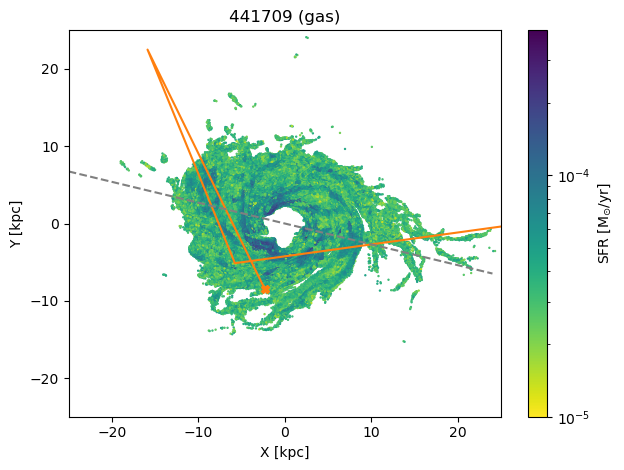

In [171]:
id = ids[0]


#load gas data
ppx2, ppy2, ppz2, ppvx2, ppvy2, ppvz2, ppm2, ppnh2, ppsfr2, ppgz2 = np.loadtxt('./%s_gas_properties_TNGv2_rotated.txt'%id, usecols=(0, 1, 2, 3, 4, 5, 6, 7,8,9), unpack = True)
#print np.min(ppsfr2), np.max(ppsfr2)

plt.scatter(ppx2, ppy2, c=ppsfr2, marker='.', s=2,norm=colors.LogNorm(vmin=1e-5, vmax=np.max(ppsfr2)), cmap='viridis_r')


plt.colorbar(label=r'SFR [M$_{\odot}$/yr]')
plt.xlim(-25,25)
plt.ylim(-25,25)

plt.title('%s (gas)'%id)
plt.xlabel('X [kpc]')
plt.ylabel('Y [kpc]')


# orbit = np.loadtxt('%s_major_merger_orbit_419487_94.txt'%ids[0])
# plt.plot(orbit[:,1], orbit[:,2])
# plt.plot(orbit[:,1][-1], orbit[:,2][-1],'o', color='C1')


## need to rotate the orbit coords to the same frame like the particles to get this right
orbit = np.loadtxt('%s_major_merger_orbit_rotated.txt'%id)
plt.plot(orbit[:,2], orbit[:,3], color='C1')
plt.plot(orbit[:,2][-1], orbit[:,3][-1], marker='X',color='C1')
m1,b1 = per_bi(orbit[:,2][-1], orbit[:,3][-1],0. ,0.)
plt.plot(np.arange(-25,25,1),np.arange(-25,25,1)*m1+b1, ls='--', c='gray')
yy1 = ppx2*m1+b1
plt.tight_layout()

In [222]:
import glob
import re

def get_available_snaps(subhalo_id, particle_type='gas'):
    pattern = f'./{subhalo_id}_{particle_type}_properties_TNGv2_snap*.txt'
    files = [f for f in glob.glob(pattern) if 'rotated' not in f]
    snaps = []
    for f in files:
        match = re.search(r'snap(\d+)\.txt$', f)
        if match:
            snaps.append(int(match.group(1)))
    return np.array(sorted(snaps))


In [227]:
for i in range(3):
    id = ids[i]
    print(id)
    snaps = get_available_snaps(id)
    print(snaps)
    #for snap in snaps:
        #rotate to the z=0 projection 
        #rotate_gas_particle_data(id, snap, analog_pos[i], analog_vel[i])
        
    

441709
[ 2  3  4  6  8 11 13 17 21 25 33 40 50 59 67 72 78 84 91]
474008
[ 2  3  4  6  8 11 13 17 21 25 33 40 50 59 67 72 78 84]
532301
[ 2  3  4  6  8 11 13 17 21 25 33 40 50 59 67 72 78]
